# V3 analysis

Loads participant V3's pairwise responses from `food_rescue_combined copy.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_all = pd.read_csv('food_rescue_combined copy.csv')
v3 = df_all[df_all['personID'] == 'V3'].copy().sort_values('num_Q').reset_index(drop=True)

print(f'V3: {len(v3)} responses')
print(f'num_Q range: {v3["num_Q"].min()}–{v3["num_Q"].max()}')
print(f'A/B counts: {v3["AorB"].value_counts().to_dict()}')
v3.head()

V3: 43 responses
num_Q range: 2–44
A/B counts: {'B': 26, 'A': 17}


,personID,food,size_A,access_A,income_A,poverty_A,last_donation_A,total_donation_A,dist_A,size_B,access_B,income_B,poverty_B,last_donation_B,total_donation_B,dist_B,num_Q,AorB
0,V3,1,4,2,2,2,11,84,0,0,0,1,3,3,28,2,2,A
1,V3,1,4,0,5,1,7,14,3,1,2,0,6,7,5,1,3,B
2,V3,0,2,0,3,1,2,35,1,3,0,2,2,0,0,1,4,B
3,V3,0,2,1,3,1,6,52,3,2,0,2,3,10,79,0,5,B
4,V3,1,3,0,3,0,8,34,0,3,2,5,1,8,73,1,6,B


In [2]:
# Label conflict queries for V3
CONFLICT_QS = [7, 8, 10, 11, 18, 35, 36, 38]
v3['conflicted'] = v3['num_Q'].isin(CONFLICT_QS)

print(f'Labeled {v3["conflicted"].sum()} / {len(CONFLICT_QS)} expected conflict queries')
missing = [q for q in CONFLICT_QS if q not in v3['num_Q'].values]
if missing:
    print(f'WARNING: queries {missing} not in V3 data')

v3[v3['conflicted']]

Labeled 8 / 8 expected conflict queries


,personID,food,size_A,access_A,income_A,poverty_A,last_donation_A,total_donation_A,dist_A,size_B,access_B,income_B,poverty_B,last_donation_B,total_donation_B,dist_B,num_Q,AorB,conflicted
5,V3,1,1,2,2,2,2,16,3,2,0,4,0,9,11,0,7,B,True
6,V3,1,0,1,5,1,5,6,1,1,0,3,1,0,0,3,8,B,True
8,V3,0,0,2,4,1,0,0,0,3,0,3,1,10,42,1,10,B,True
9,V3,1,3,1,4,1,0,0,0,1,2,4,0,5,17,3,11,A,True
16,V3,0,1,1,1,0,1,8,1,3,0,3,1,6,19,0,18,B,True
33,V3,1,3,2,2,2,0,0,0,2,1,1,4,8,77,0,35,A,True
34,V3,1,2,0,5,1,0,0,1,2,1,1,3,10,9,3,36,B,True
36,V3,0,2,2,5,1,7,70,0,1,1,3,1,7,57,1,38,A,True


## Algorithm comparison: 5 methods, 2 conceptual questions

We fit five inference methods to V3's 43 pairwise responses (8 conflicted). All five use hit-and-run MCMC on the simplex; they differ in which responses they use and how the response likelihood is defined.

The downstream analysis splits into **two conceptual comparisons**:

- **Part 1 — Value of using conflict.** Utilize-Indecision (BP) vs Ignore-Indecision (BT-drop conflict) vs Force-Decision (BT-force conflict). Asks whether modelling indecision *as such* helps, holding the BT logistic backbone fixed.
- **Part 2 — Comparison against baselines that model incomparability.** Utilize-Indecision (BP) vs Rao-Kupper (θ≥1) vs Davidson (ν≥0). Compares our method against classical tie extensions of Bradley-Terry.

**Method definitions**

- **Bayes Polytope (BP) — "Utilize-Indecision".** Uses all responses including conflicted (mapped to *incomparable*). 4-tier likelihood with thresholds τ, τ' and closed-form logistic noise.
- **BT MCMC (drop) — "Ignore-Indecision".** Only decisive (A/B) responses; conflicted are dropped.
- **BT MCMC (force) — "Force-Decision".** All responses with V3's reported A/B choice as a hard label, including conflicted.
- **Rao-Kupper (θ≥1).** All responses with explicit tie threshold θ; conflicted are *incomparable*. Reduces to BT at θ=1.
- **Davidson (ν≥0).** All responses with tie parameter ν; preserves Luce odds ratio $P(\text{left})/P(\text{right}) = e^\Delta$. Reduces to BT at ν=0.

Posterior uncertainty = total variance ∑ Var[ωₖ].


In [3]:
from scipy.special import expit as _sigmoid

FEATURES = ['size', 'access', 'income', 'poverty', 'last_donation', 'dist']
SIGN     = np.array([1, 1, -1, 1, -1, -1], dtype=float)   # +1 keep, -1 flip (raw → priority)
_NDIM    = len(FEATURES)

all_vals = np.concatenate([
    df_all[[f+'_A' for f in FEATURES]].values,
    df_all[[f+'_B' for f in FEATURES]].values
], axis=0)
F_MIN = all_vals.min(axis=0); F_MAX = all_vals.max(axis=0)

def process_features(raw):
    rng = np.where(F_MAX > F_MIN, F_MAX - F_MIN, 1.0)
    normed = (raw - F_MIN) / rng
    return np.where(SIGN == 1, normed, 1.0 - normed)

xA = process_features(v3[[f+'_A' for f in FEATURES]].values)
xB = process_features(v3[[f+'_B' for f in FEATURES]].values)

def _map_response(row):
    if row['conflicted']:
        return 'incomparable'
    return 'left' if row['AorB'] == 'A' else 'right'

v3_transcript = [(xA[i], xB[i], _map_response(v3.iloc[i])) for i in range(len(v3))]

from collections import Counter
print(f'V3 transcript: {len(v3_transcript)} responses')
print(Counter(r for _, _, r in v3_transcript))

V3 transcript: 43 responses
Counter({'right': 21, 'left': 14, 'incomparable': 8})


In [4]:
# ── MCMC samplers (BP closed-form, BT exact, RK & Davidson) ──────────────
# Hit-and-run on the simplex for ω; reflected Gaussian RW for the tie param.

_TAU       = 0.0      # indifference threshold (V3 has no indifference labels)
_TAU_PRIME = 0.25     # BP τ_κ default; can be reassigned by polytope inference
_LAMBDA_X  = 1.0

# Rao-Kupper (θ ≥ 1)
_RK_THETA_MAX  = 10.0
_RK_THETA_STEP = 0.30
_RK_THETA_INIT = 1.50

# Davidson (ν ≥ 0)
_DV_NU_MAX  = 10.0
_DV_NU_STEP = 0.30
_DV_NU_INIT = 0.50


# ── Hit-and-run proposal on the simplex (shared) ─────────────────────────
def _hit_run_step(x, rng):
    dim = len(x)
    d = rng.standard_normal(dim); d -= d.mean()
    n = np.linalg.norm(d)
    if n < 1e-12: return x.copy()
    d /= n
    t_lo, t_hi = -np.inf, np.inf
    for j in range(dim):
        if   d[j] >  1e-12: t_lo = max(t_lo, -x[j]/d[j])
        elif d[j] < -1e-12: t_hi = min(t_hi, -x[j]/d[j])
    if t_lo >= t_hi - 1e-12: return x.copy()
    nx = x + rng.uniform(t_lo, t_hi) * d
    nx = np.maximum(nx, 0.); nx /= nx.sum()
    return nx

# ── Bayes Polytope (closed-form 4-tier likelihood) ───────────────────────
def _frame_gaps(q, lx=_LAMBDA_X):
    diff   = q[0] - q[1]
    gaps   = lx * diff
    active = set(np.where(np.abs(gaps) > 0)[0].tolist())
    return gaps, active

def _response_probs_mc(q, w, n_mc=100, rng=None):
    """Closed-form P(resp|q,w). n_mc/rng unused (kept for backwards compat)."""
    gaps, active = _frame_gaps(q)
    delta = float(np.dot(gaps, w))
    r     = float(sum(w[j] * abs(gaps[j]) for j in active))
    if r < _TAU:
        return np.array([0.0, 0.0, 1.0, 0.0])
    th = _TAU_PRIME * r
    p_left  = float(_sigmoid(delta - th))
    p_right = float(_sigmoid(-(delta + th)))
    p_inc   = max(0.0, 1.0 - p_left - p_right)
    return np.array([p_left, p_right, 0.0, p_inc])

def _transcript_ll(transcript, w, n_mc=50, rng=None):
    idx = {'left': 0, 'right': 1, 'indifferent': 2, 'incomparable': 3}
    ll = 0.0
    for q in transcript:
        probs = _response_probs_mc(q, w)
        ll += np.log(max(probs[idx[q[2]]], 1e-10))
    return ll

def sample_bayes_polytope(transcript, n_samples=500, burn_in=500, n_mc=50, rng=None):
    if rng is None: rng = np.random.default_rng()
    w  = np.ones(_NDIM) / _NDIM
    ll = _transcript_ll(transcript, w)
    samples, n_acc = [], 0
    for step in range(burn_in + n_samples):
        wp  = _hit_run_step(w, rng)
        llp = _transcript_ll(transcript, wp)
        if np.log(max(rng.random(), 1e-15)) < llp - ll:
            w, ll = wp, llp
            if step >= burn_in: n_acc += 1
        if step >= burn_in: samples.append(w.copy())
    return np.array(samples), n_acc / max(1, n_samples)

# ── Standard Bradley-Terry (decisive only) ────────────────────────────────
def sample_bt_mcmc(phis, ys, n_samples=500, burn_in=500, rng=None):
    if rng is None: rng = np.random.default_rng()
    if len(phis) == 0:
        return rng.dirichlet(np.ones(_NDIM), size=n_samples), 1.0
    def log_likelihood(w):
        lg = phis @ w
        lp  = np.where(lg >= 0, -np.log1p(np.exp(-lg)), lg - np.log1p(np.exp(lg)))
        lnp = np.where(lg >= 0, -lg - np.log1p(np.exp(-lg)), -np.log1p(np.exp(lg)))
        return float(np.sum(ys * lp + (1 - ys) * lnp))
    w  = np.ones(_NDIM) / _NDIM
    lp = log_likelihood(w)
    samples, n_acc = [], 0
    for step in range(burn_in + n_samples):
        wp  = _hit_run_step(w, rng)
        lpp = log_likelihood(wp)
        if np.log(max(rng.random(), 1e-15)) < lpp - lp:
            w, lp = wp, lpp
            if step >= burn_in: n_acc += 1
        if step >= burn_in: samples.append(w.copy())
    return np.array(samples), n_acc / max(1, n_samples)

# ── Rao-Kupper (standard θ ≥ 1 parameterisation) ─────────────────────────
# π_i/π_j = exp(Δ), θ ≥ 1.
#   P(left)  = 1 / (1 + θ·e^{-Δ})
#   P(right) = 1 / (1 + θ·e^{ Δ})
#   P(tie)   = (θ²-1) / [(1 + θ·e^{-Δ})(1 + θ·e^{ Δ})]
# Reduces to BT when θ=1 (P(tie)=0). Does NOT preserve Luce except at θ=1.
def _rk_log_probs(delta, theta):
    log_theta    = np.log(theta)
    log_term_pos = np.logaddexp(0.0, log_theta + delta)   # log(1 + θ·e^{Δ})
    log_term_neg = np.logaddexp(0.0, log_theta - delta)   # log(1 + θ·e^{-Δ})
    log_p_left   = -log_term_neg
    log_p_right  = -log_term_pos
    if theta > 1.0:
        # log(θ²-1) = log(θ-1) + log(θ+1) — split form for stability near θ=1
        log_p_tie = np.log(theta - 1.0) + np.log(theta + 1.0) - log_term_neg - log_term_pos
    else:
        log_p_tie = -np.inf
    return log_p_left, log_p_right, log_p_tie

def _rk_log_likelihood(phis, responses, w, theta):
    ll = 0.0
    for phi, resp in zip(phis, responses):
        delta = float(np.dot(phi, w))
        lpl, lpr, lpt = _rk_log_probs(delta, theta)
        if   resp == 'left':         ll += lpl
        elif resp == 'right':        ll += lpr
        elif resp == 'incomparable': ll += lpt if not np.isinf(lpt) else -1e10
    return ll

def sample_rk_mcmc(phis, responses, n_samples=500, burn_in=500,
                   theta_step=_RK_THETA_STEP, rng=None,
                   theta_init=_RK_THETA_INIT, theta_max=_RK_THETA_MAX):
    """Block-Gibbs MH on (ω, θ) for Rao-Kupper. Hit-and-run on simplex for ω,
    reflected Gaussian RW above θ=1 for θ. Returns (samples, acc_w, acc_θ).
    Last column of samples is θ."""
    if rng is None: rng = np.random.default_rng()
    w     = np.ones(_NDIM) / _NDIM
    theta = float(theta_init)
    ll    = _rk_log_likelihood(phis, responses, w, theta)
    samples, n_acc_w, n_acc_th = [], 0, 0
    for step in range(burn_in + n_samples):
        # ω update
        wp  = _hit_run_step(w, rng)
        llp = _rk_log_likelihood(phis, responses, wp, theta)
        if np.log(max(rng.random(), 1e-15)) < llp - ll:
            w, ll = wp, llp
            if step >= burn_in: n_acc_w += 1
        # θ update — reflect at θ=1 (symmetric proposal)
        x = theta + rng.normal(0, theta_step)
        theta_p = (2.0 - x) if x < 1.0 else x
        if theta_p <= theta_max:
            llp = _rk_log_likelihood(phis, responses, w, theta_p)
            if np.log(max(rng.random(), 1e-15)) < llp - ll:
                theta, ll = theta_p, llp
                if step >= burn_in: n_acc_th += 1
        if step >= burn_in:
            samples.append(np.append(w.copy(), theta))
    return np.array(samples), n_acc_w / max(1, n_samples), n_acc_th / max(1, n_samples)

# ── Davidson (ν ≥ 0) ─────────────────────────────────────────────────────
# π_i/π_j = exp(Δ), ν ≥ 0.
#   P(left)  = e^{ Δ/2} / Z
#   P(right) = e^{-Δ/2} / Z
#   P(tie)   = ν / Z
#   Z        = e^{Δ/2} + e^{-Δ/2} + ν       (= 2 cosh(Δ/2) + ν)
# Reduces to BT when ν=0. Preserves the Luce odds-ratio: P(left)/P(right) = e^Δ.
def _davidson_log_probs(delta, nu):
    half = 0.5 * delta
    if nu > 0:
        log_nu = np.log(nu)
        log_z  = np.logaddexp(np.logaddexp(half, -half), log_nu)
        log_p_tie = log_nu - log_z
    else:
        log_z  = np.logaddexp(half, -half)        # log(2 cosh(Δ/2))
        log_p_tie = -np.inf
    log_p_left  =  half - log_z
    log_p_right = -half - log_z
    return log_p_left, log_p_right, log_p_tie

def _davidson_log_likelihood(phis, responses, w, nu):
    ll = 0.0
    for phi, resp in zip(phis, responses):
        delta = float(np.dot(phi, w))
        lpl, lpr, lpt = _davidson_log_probs(delta, nu)
        if   resp == 'left':         ll += lpl
        elif resp == 'right':        ll += lpr
        elif resp == 'incomparable': ll += lpt if not np.isinf(lpt) else -1e10
    return ll

def sample_davidson_mcmc(phis, responses, n_samples=500, burn_in=500,
                         nu_step=_DV_NU_STEP, rng=None,
                         nu_init=_DV_NU_INIT, nu_max=_DV_NU_MAX):
    """Block-Gibbs MH on (ω, ν) for Davidson tie model. Hit-and-run on simplex
    for ω, reflected Gaussian RW above ν=0 for ν. Returns (samples, acc_w, acc_ν).
    Last column of samples is ν."""
    if rng is None: rng = np.random.default_rng()
    w  = np.ones(_NDIM) / _NDIM
    nu = float(nu_init)
    ll = _davidson_log_likelihood(phis, responses, w, nu)
    samples, n_acc_w, n_acc_nu = [], 0, 0
    for step in range(burn_in + n_samples):
        wp  = _hit_run_step(w, rng)
        llp = _davidson_log_likelihood(phis, responses, wp, nu)
        if np.log(max(rng.random(), 1e-15)) < llp - ll:
            w, ll = wp, llp
            if step >= burn_in: n_acc_w += 1
        # ν update — reflect at ν=0
        nu_p = abs(nu + rng.normal(0, nu_step))
        if nu_p <= nu_max:
            llp = _davidson_log_likelihood(phis, responses, w, nu_p)
            if np.log(max(rng.random(), 1e-15)) < llp - ll:
                nu, ll = nu_p, llp
                if step >= burn_in: n_acc_nu += 1
        if step >= burn_in:
            samples.append(np.append(w.copy(), nu))
    return np.array(samples), n_acc_w / max(1, n_samples), n_acc_nu / max(1, n_samples)

print('Algorithms defined: sample_bayes_polytope, sample_bt_mcmc, sample_rk_mcmc, sample_davidson_mcmc')

Algorithms defined: sample_bayes_polytope, sample_bt_mcmc, sample_rk_mcmc, sample_davidson_mcmc


In [5]:
# ── Run all 5 algorithms on V3's full transcript ────────────────────────
N_MCMC  = 500
BURN_IN = 500
BP_NMC  = 200

phis_all      = np.array([q[0] - q[1] for q in v3_transcript])
responses_all = [q[2] for q in v3_transcript]
phis_dec   = np.array([q[0] - q[1] for q in v3_transcript if q[2] in ('left','right')])
ys_dec     = np.array([1.0 if q[2] == 'left' else 0.0 for q in v3_transcript if q[2] in ('left','right')])

phis_forced = phis_all
ys_forced   = (v3['AorB'] == 'A').astype(float).values

rng_bp = np.random.default_rng(42)
rng_bt = np.random.default_rng(43)
rng_rk = np.random.default_rng(44)
rng_bf = np.random.default_rng(45)
rng_dv = np.random.default_rng(46)

bp_samples, bp_acc            = sample_bayes_polytope(v3_transcript, N_MCMC, BURN_IN, n_mc=BP_NMC, rng=rng_bp)
bt_samples, bt_acc            = sample_bt_mcmc(phis_dec, ys_dec, N_MCMC, BURN_IN, rng=rng_bt)
rk_samples, rk_acc_w, rk_acc_t = sample_rk_mcmc(phis_all, responses_all, N_MCMC, BURN_IN, rng=rng_rk)
bf_samples, bf_acc            = sample_bt_mcmc(phis_forced, ys_forced, N_MCMC, BURN_IN, rng=rng_bf)
dv_samples, dv_acc_w, dv_acc_n = sample_davidson_mcmc(phis_all, responses_all, N_MCMC, BURN_IN, rng=rng_dv)

bp_var = bp_samples.var(axis=0).sum()
bt_var = bt_samples.var(axis=0).sum()
rk_var = rk_samples[:, :_NDIM].var(axis=0).sum()
bf_var = bf_samples.var(axis=0).sum()
dv_var = dv_samples[:, :_NDIM].var(axis=0).sum()

def directional_pred_acc(omega):
    pred = (phis_dec @ omega) > 0
    return float((pred == ys_dec.astype(bool)).mean())

header = f'{"":22s} {"accept":>7s}  {"pred%":>6s}  {"total var":>10s}  posterior mean ω'
print(header)
print('-' * 90)
for label, samp, accpt, var in [
    ('Bayes Polytope',     bp_samples,            bp_acc,    bp_var),
    ('BT (drop conflict)', bt_samples,            bt_acc,    bt_var),
    ('Rao-Kupper',         rk_samples[:, :_NDIM], rk_acc_w,  rk_var),
    ('Davidson',           dv_samples[:, :_NDIM], dv_acc_w,  dv_var),
    ('BT (force conflict)',bf_samples,            bf_acc,    bf_var),
]:
    om   = '  '.join(f'{v:.3f}' for v in samp.mean(axis=0))
    pred = directional_pred_acc(samp.mean(axis=0))
    print(f'{label:22s} {accpt:>7.2f}  {pred:>6.1%}  {var:>10.5f}  {om}')

print(f'\nFeatures: {FEATURES}')
print(f'\nRK θ posterior:   mean={rk_samples[:,-1].mean():.3f}  median={np.median(rk_samples[:,-1]):.3f}  acc_θ={rk_acc_t:.2f}')
print(f'Davidson ν post:  mean={dv_samples[:,-1].mean():.3f}  median={np.median(dv_samples[:,-1]):.3f}  acc_ν={dv_acc_n:.2f}')

                        accept   pred%   total var  posterior mean ω
------------------------------------------------------------------------------------------
Bayes Polytope            0.87   88.6%     0.10411  0.142  0.165  0.148  0.105  0.215  0.226
BT (drop conflict)        0.93   94.3%     0.10178  0.127  0.139  0.207  0.167  0.134  0.226
Rao-Kupper                0.89   97.1%     0.10179  0.241  0.156  0.205  0.124  0.094  0.179
Davidson                  0.92   94.3%     0.09752  0.285  0.123  0.138  0.179  0.119  0.156
BT (force conflict)       0.89   94.3%     0.09718  0.249  0.108  0.166  0.184  0.117  0.176

Features: ['size', 'access', 'income', 'poverty', 'last_donation', 'dist']

RK θ posterior:   mean=1.666  median=1.643  acc_θ=0.61
Davidson ν post:  mean=0.559  median=0.526  acc_ν=0.61


In [6]:
# ── V3's manual model ω (max-points convention: ω_f ∝ max(scores)) ─────────
MANUAL_CSV = {
    'size':          'Manual scoring model database_sheet.xlsx - organization_size.csv',
    'access':        'Manual scoring model database_sheet.xlsx - access.csv',
    'income':        'Manual scoring model database_sheet.xlsx - income.csv',
    'poverty':       'Manual scoring model database_sheet.xlsx - poverty.csv',
    'last_donation': 'Manual scoring model database_sheet.xlsx - last_donation.csv',
    'dist':          'Manual scoring model database_sheet.xlsx - distance.csv',
}

manual_max   = {}
manual_range = {}
for feat, fname in MANUAL_CSV.items():
    raw = pd.read_csv(fname).set_index('person')
    raw = raw.apply(pd.to_numeric, errors='coerce')
    manual_max[feat]   = raw.loc['V3'].max()
    manual_range[feat] = raw.loc['V3'].max() - raw.loc['V3'].min()

raw_max   = np.array([manual_max[f]   for f in FEATURES])
raw_range = np.array([manual_range[f] for f in FEATURES])

om_manual_max   = raw_max   / raw_max.sum()
om_manual_range = raw_range / raw_range.sum()
om_manual       = om_manual_max         # primary anchor (max-points)

print(f'V3 manual scoring per feature:')
print(f'{"feature":>14s}  {"max":>5s}  {"range":>6s}  {"ω_max":>6s}  {"ω_range":>8s}')
for i, f in enumerate(FEATURES):
    print(f'{f:>14s}  {raw_max[i]:>5.0f}  {raw_range[i]:>6.0f}  '
          f'{om_manual_max[i]:>6.3f}  {om_manual_range[i]:>8.3f}')

# Side-by-side: manual (max) vs all 5 fitted methods
om_bp = bp_samples.mean(axis=0)
om_bt = bt_samples.mean(axis=0)
om_rk = rk_samples[:, :_NDIM].mean(axis=0)
om_dv = dv_samples[:, :_NDIM].mean(axis=0)
om_bf = bf_samples.mean(axis=0)

header = (f'{"feature":>14s}  {"manual":>7s}  '
          f'{"ω_BP":>6s}  {"ω_BT":>6s}  {"ω_RK":>6s}  {"ω_DV":>6s}  {"ω_BF":>6s}')
print('\n' + header)
print('-' * len(header))
for i, f in enumerate(FEATURES):
    print(f'{f:>14s}  {om_manual[i]:>7.3f}  '
          f'{om_bp[i]:>6.3f}  {om_bt[i]:>6.3f}  {om_rk[i]:>6.3f}  {om_dv[i]:>6.3f}  {om_bf[i]:>6.3f}')

V3 manual scoring per feature:
       feature    max   range   ω_max   ω_range
          size     20      15   0.091     0.064
        access     20      20   0.091     0.085
        income     50      50   0.227     0.214
       poverty     40      40   0.182     0.171
 last_donation     30      29   0.136     0.124
          dist     60      80   0.273     0.342

       feature   manual    ω_BP    ω_BT    ω_RK    ω_DV    ω_BF
---------------------------------------------------------------
          size    0.091   0.142   0.127   0.241   0.285   0.249
        access    0.091   0.165   0.139   0.156   0.123   0.108
        income    0.227   0.148   0.207   0.205   0.138   0.166
       poverty    0.182   0.105   0.167   0.124   0.179   0.184
 last_donation    0.136   0.215   0.134   0.094   0.119   0.117
          dist    0.273   0.226   0.226   0.179   0.156   0.176


NO τ_κ admits strict feasibility under V3's labels.
Soft-best τ_κ: 0.180  (min max-violation = 0.1047)

Inferred ω at best τ_κ:
            size: 0.104
          access: 0.205
          income: 0.290
         poverty: 0.157
   last_donation: 0.074
            dist: 0.170


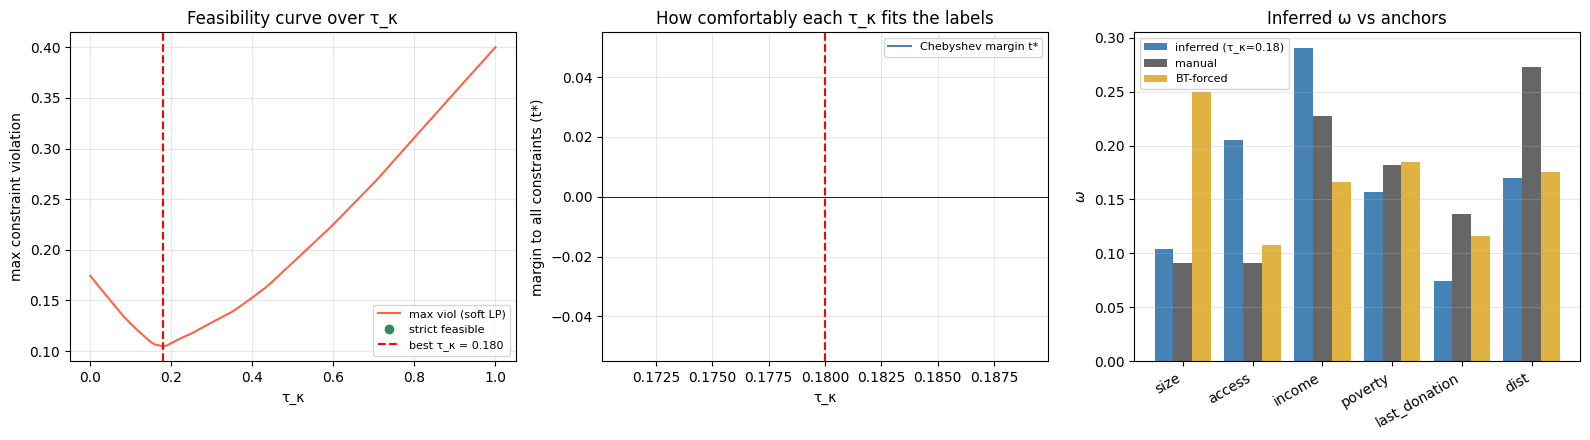

Saved v3_polytope_tau_inference.png


In [7]:
# ── Inferring τ_κ from V3's labels via parallel feasibility sets ──────────
# τ_r = 0 (V3 has no indifference responses), so the only ½S ≥ τ_r constraint is trivial.
# For each candidate τ_κ on a grid, the constraints from V3's responses are LINEAR in ω:
#
#   ≻ (chose A):     g_s(ω) ≥ τ_κ · S_s(ω)         ⟺  (φ_s − τ_κ|φ_s|)·ω ≥ 0
#   ≺ (chose B):    −g_s(ω) ≥ τ_κ · S_s(ω)         ⟺  (φ_s + τ_κ|φ_s|)·ω ≤ 0
#   ⋈ (conflict):   |g_s(ω)| ≤ τ_κ · S_s(ω)         ⟺  both directions above
#
# Plus simplex: ω ≥ 0, Σω = 1. We solve a feasibility LP per τ_κ. If V3's labels are
# inconsistent under strict feasibility we also report a soft version (min max violation).

from scipy.optimize import linprog

phis_v3 = np.array([q[0] - q[1] for q in v3_transcript])     # (43, 6)
resp_v3 = [q[2] for q in v3_transcript]

def build_constraints(phis, resps, tau_kappa):
    """Return A_ub matrix where each row · ω ≤ 0 encodes one linear constraint."""
    rows = []
    for phi, resp in zip(phis, resps):
        ap = np.abs(phi)
        if   resp == 'left':         rows.append(-(phi - tau_kappa * ap))   # ≻
        elif resp == 'right':        rows.append( (phi + tau_kappa * ap))   # ≺
        elif resp == 'incomparable':                                          # ⋈ → both
            rows.append( (phi - tau_kappa * ap))
            rows.append(-(phi + tau_kappa * ap))
    return np.array(rows)

def feasibility_strict(phis, resps, tau_kappa, ndim):
    A_ub = build_constraints(phis, resps, tau_kappa)
    res = linprog(
        c=np.zeros(ndim),
        A_ub=A_ub, b_ub=np.zeros(len(A_ub)),
        A_eq=np.ones((1, ndim)), b_eq=np.array([1.0]),
        bounds=[(0, None)] * ndim, method='highs',
    )
    return res.success, (res.x if res.success else None)

def feasibility_soft(phis, resps, tau_kappa, ndim):
    """Minimize max constraint violation s ≥ 0 over (ω, s). Returns (s*, ω)."""
    A = build_constraints(phis, resps, tau_kappa)
    n = len(A)
    # variables: [ω_0..ω_{ndim-1}, s] — constraint A·ω − s ≤ 0
    A_ub = np.column_stack([A, -np.ones(n)])
    A_eq = np.zeros((1, ndim + 1)); A_eq[0, :ndim] = 1
    res = linprog(
        c=np.r_[np.zeros(ndim), 1.0],
        A_ub=A_ub, b_ub=np.zeros(n),
        A_eq=A_eq, b_eq=np.array([1.0]),
        bounds=[(0, None)] * ndim + [(0, None)],
        method='highs',
    )
    if not res.success:
        return np.inf, None
    return float(res.fun), res.x[:ndim]

def chebyshev_center(phis, resps, tau_kappa, ndim):
    """Find ω that maximises margin to all constraints (analogous to Chebyshev center).
    Solves: max t  s.t.  A·ω + t·1 ≤ 0, ω∈Δ.
    Only meaningful if t* ≥ 0 (otherwise polytope is empty)."""
    A = build_constraints(phis, resps, tau_kappa)
    n = len(A)
    A_ub = np.column_stack([A,  np.ones(n)])
    A_eq = np.zeros((1, ndim + 1)); A_eq[0, :ndim] = 1
    res = linprog(
        c=np.r_[np.zeros(ndim), -1.0],   # maximize t = minimize −t
        A_ub=A_ub, b_ub=np.zeros(n),
        A_eq=A_eq, b_eq=np.array([1.0]),
        bounds=[(0, None)] * ndim + [(None, None)],
        method='highs',
    )
    if not res.success:
        return -np.inf, None
    return float(-res.fun), res.x[:ndim]

# ── Sweep τ_κ ──────────────────────────────────────────────────────────────
tau_grid = np.linspace(0.0, 1.0, 101)
feasible_flags = []
max_viol      = []
margin_t      = []
omegas        = []

for tk in tau_grid:
    ok, w_strict = feasibility_strict(phis_v3, resp_v3, tk, _NDIM)
    s_soft, w_soft = feasibility_soft(phis_v3, resp_v3, tk, _NDIM)
    t_cheb, w_cheb = chebyshev_center(phis_v3, resp_v3, tk, _NDIM) if ok else (-np.inf, None)
    feasible_flags.append(ok)
    max_viol.append(s_soft)
    margin_t.append(t_cheb)
    omegas.append(w_cheb if ok else w_soft)

feasible_flags = np.array(feasible_flags)
max_viol = np.array(max_viol)
margin_t = np.array(margin_t)

feas_idx = np.where(feasible_flags)[0]
if len(feas_idx) > 0:
    tk_lo = tau_grid[feas_idx[0]]
    tk_hi = tau_grid[feas_idx[-1]]
    print(f'STRICT FEASIBILITY:  τ_κ ∈ [{tk_lo:.3f}, {tk_hi:.3f}]   ({len(feas_idx)} of {len(tau_grid)} grid points)')
    # Best τ_κ: the one with the largest Chebyshev margin (most slack to all constraints)
    best_idx = feas_idx[np.argmax(margin_t[feas_idx])]
    tau_inferred = tau_grid[best_idx]
    omega_inferred = omegas[best_idx]
    print(f'BEST τ_κ (largest constraint margin): {tau_inferred:.3f}  (margin t* = {margin_t[best_idx]:+.4f})')
else:
    # No τ_κ admits the labels strictly — pick the τ_κ with smallest violation
    best_idx = int(np.argmin(max_viol))
    tau_inferred = tau_grid[best_idx]
    omega_inferred = omegas[best_idx]
    print('NO τ_κ admits strict feasibility under V3\'s labels.')
    print(f'Soft-best τ_κ: {tau_inferred:.3f}  (min max-violation = {max_viol[best_idx]:.4f})')

print('\nInferred ω at best τ_κ:')
for f, v in zip(FEATURES, omega_inferred):
    print(f'  {f:>14s}: {v:.3f}')

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.plot(tau_grid, max_viol, '-', color='tomato', label='max viol (soft LP)')
ax.plot(tau_grid, np.where(feasible_flags, 0.0, np.nan), 'o', color='seagreen', label='strict feasible')
ax.axvline(tau_inferred, color='red', ls='--', label=f'best τ_κ = {tau_inferred:.3f}')
ax.set_xlabel('τ_κ'); ax.set_ylabel('max constraint violation')
ax.set_title('Feasibility curve over τ_κ')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(tau_grid, margin_t, '-', color='steelblue', label='Chebyshev margin t*')
ax.axhline(0, color='k', lw=0.6)
ax.axvline(tau_inferred, color='red', ls='--')
ax.set_xlabel('τ_κ'); ax.set_ylabel('margin to all constraints (t*)')
ax.set_title('How comfortably each τ_κ fits the labels')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
x = np.arange(_NDIM); width = 0.27
ax.bar(x - width, omega_inferred, width, label=f'inferred (τ_κ={tau_inferred:.2f})', color='steelblue')
ax.bar(x,         om_manual,      width, label='manual',       color='black', alpha=0.6)
ax.bar(x + width, om_bf,          width, label='BT-forced',    color='goldenrod', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(FEATURES, rotation=30, ha='right')
ax.set_ylabel(r'$\omega$'); ax.set_title('Inferred ω vs anchors')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('v3_polytope_tau_inference.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved v3_polytope_tau_inference.png')

# Expose for downstream cells
tau_kappa_polytope = tau_inferred
omega_polytope     = omega_inferred

       feature   manual   BP(τ=.25)  BP(τ=infer)   polytope
-----------------------------------------------------------
          size    0.091       0.142        0.111      0.104
        access    0.091       0.165        0.184      0.205
        income    0.227       0.148        0.239      0.290
       poverty    0.182       0.105        0.072      0.157
 last_donation    0.136       0.215        0.131      0.074
          dist    0.273       0.226        0.262      0.170

  τ_κ default  = 0.250    BP variance = 0.10411    accept = 0.87
  τ_κ inferred = 0.180    BP variance = 0.12360    accept = 0.90


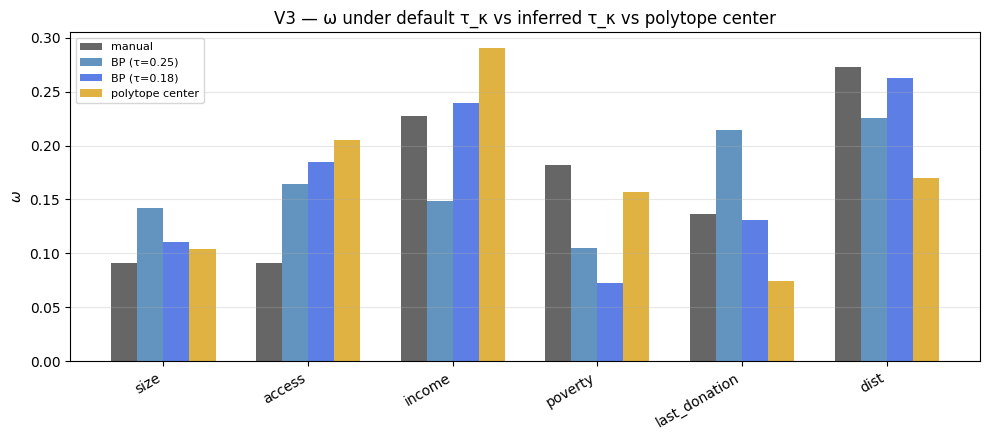

Saved v3_bp_inferred_tau.png


In [8]:
# ── Re-run BP MCMC with the τ_κ inferred from V3's labels ─────────────────
# Compares the posterior mean ω under the inferred τ_κ vs. the default τ_κ = 0.25.
# (_TAU_PRIME is a module-global; reassigning it changes what the closed-form
#  likelihood inside _response_probs_mc uses on the next call.)

_TAU_PRIME_DEFAULT = 0.25                       # original default
_TAU_PRIME_INFERRED = float(tau_kappa_polytope) # from polytope inference

# Run BP under inferred τ_κ
_TAU_PRIME = _TAU_PRIME_INFERRED
rng_bpi = np.random.default_rng(2024)
bpi_samples, bpi_acc = sample_bayes_polytope(v3_transcript, N_MCMC, BURN_IN, rng=rng_bpi)
om_bp_inferred = bpi_samples.mean(axis=0)
bpi_var        = bpi_samples.var(axis=0).sum()

# Restore default for any other downstream cells that expect it
_TAU_PRIME = _TAU_PRIME_DEFAULT

# Compare
header = f'{"feature":>14s}  {"manual":>7s}  {"BP(τ=.25)":>10s}  {"BP(τ=infer)":>11s}  {"polytope":>9s}'
print(header); print('-' * len(header))
for i, f in enumerate(FEATURES):
    print(f'{f:>14s}  {om_manual[i]:>7.3f}  {om_bp[i]:>10.3f}  '
          f'{om_bp_inferred[i]:>11.3f}  {omega_polytope[i]:>9.3f}')

print(f'\n  τ_κ default  = {_TAU_PRIME_DEFAULT:.3f}    BP variance = {bp_samples.var(axis=0).sum():.5f}    accept = {bp_acc:.2f}')
print(f'  τ_κ inferred = {_TAU_PRIME_INFERRED:.3f}    BP variance = {bpi_var:.5f}    accept = {bpi_acc:.2f}')

# Plot side-by-side ω comparison
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(_NDIM); width = 0.18
ax.bar(x - 1.5*width, om_manual,        width, label='manual',           color='black',    alpha=0.6)
ax.bar(x - 0.5*width, om_bp,            width, label=f'BP (τ=0.25)',     color='steelblue', alpha=0.85)
ax.bar(x + 0.5*width, om_bp_inferred,   width, label=f'BP (τ={_TAU_PRIME_INFERRED:.2f})',
        color='royalblue', alpha=0.85)
ax.bar(x + 1.5*width, omega_polytope,   width, label='polytope center',  color='goldenrod', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(FEATURES, rotation=30, ha='right')
ax.set_ylabel(r'$\omega$')
ax.set_title(f'V3 — ω under default τ_κ vs inferred τ_κ vs polytope center')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('v3_bp_inferred_tau.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved v3_bp_inferred_tau.png')

In [9]:
# ── Learning curve with τ_κ inferred (BP) — also includes Davidson ───────
_TAU_PRIME_SAVED = _TAU_PRIME
_TAU_PRIME = float(tau_kappa_polytope)
print(f'Using inferred τ_κ = {_TAU_PRIME:.3f} for BP runs in this cell.')

N_VALUES   = [5, 10, 15, 20, 25, 30, 35, len(v3_transcript)]
N_MCMC_LC  = 300
BURN_LC    = 300

lc = {'BP': [], 'BT': [], 'RK': [], 'DV': [], 'BF': []}
header = f'{"N":>4s}  {"BP":>8s}  {"BT":>8s}  {"RK":>8s}  {"DV":>8s}  {"BF":>8s}  {"BT n_dec":>8s}  {"# conf":>7s}'
print(header)
for N in N_VALUES:
    tr_N    = v3_transcript[:N]
    phis_N  = np.array([q[0] - q[1] for q in tr_N])
    resps_N = [q[2] for q in tr_N]
    phis_d  = np.array([q[0] - q[1] for q in tr_N if q[2] in ('left','right')])
    ys_d    = np.array([1.0 if q[2] == 'left' else 0.0 for q in tr_N if q[2] in ('left','right')])
    ys_f    = (v3['AorB'].values[:N] == 'A').astype(float)

    bp_s, _    = sample_bayes_polytope(tr_N, N_MCMC_LC, BURN_LC, rng=np.random.default_rng(100+N))
    bt_s, _    = sample_bt_mcmc(phis_d, ys_d, N_MCMC_LC, BURN_LC, rng=np.random.default_rng(200+N))
    rk_s, _, _ = sample_rk_mcmc(phis_N, resps_N, N_MCMC_LC, BURN_LC, rng=np.random.default_rng(300+N))
    dv_s, _, _ = sample_davidson_mcmc(phis_N, resps_N, N_MCMC_LC, BURN_LC, rng=np.random.default_rng(500+N))
    bf_s, _    = sample_bt_mcmc(phis_N, ys_f, N_MCMC_LC, BURN_LC, rng=np.random.default_rng(400+N))

    lc['BP'].append(bp_s.var(axis=0).sum())
    lc['BT'].append(bt_s.var(axis=0).sum())
    lc['RK'].append(rk_s[:, :_NDIM].var(axis=0).sum())
    lc['DV'].append(dv_s[:, :_NDIM].var(axis=0).sum())
    lc['BF'].append(bf_s.var(axis=0).sum())
    n_conf = sum(1 for r in resps_N if r == 'incomparable')
    print(f'{N:>4d}  {lc["BP"][-1]:>8.5f}  {lc["BT"][-1]:>8.5f}  '
          f'{lc["RK"][-1]:>8.5f}  {lc["DV"][-1]:>8.5f}  {lc["BF"][-1]:>8.5f}  '
          f'{len(ys_d):>8d}  {n_conf:>7d}')

# Re-fit the 'final' samples under inferred τ_κ for the bar plot below
rng_bp = np.random.default_rng(42)
rng_bt = np.random.default_rng(43)
rng_rk = np.random.default_rng(44)
rng_bf = np.random.default_rng(45)
rng_dv = np.random.default_rng(46)
bp_samples, bp_acc            = sample_bayes_polytope(v3_transcript, N_MCMC, BURN_IN, rng=rng_bp)
bt_samples, bt_acc            = sample_bt_mcmc(phis_dec, ys_dec, N_MCMC, BURN_IN, rng=rng_bt)
rk_samples, rk_acc_w, rk_acc_t = sample_rk_mcmc(phis_all, responses_all, N_MCMC, BURN_IN, rng=rng_rk)
dv_samples, dv_acc_w, dv_acc_n = sample_davidson_mcmc(phis_all, responses_all, N_MCMC, BURN_IN, rng=rng_dv)
bf_samples, bf_acc            = sample_bt_mcmc(phis_forced, ys_forced, N_MCMC, BURN_IN, rng=rng_bf)


Using inferred τ_κ = 0.180 for BP runs in this cell.
   N        BP        BT        RK        DV        BF  BT n_dec   # conf
   5   0.09521   0.11254   0.09700   0.09102   0.10504         5        0
  10   0.08848   0.11233   0.08102   0.08659   0.09239         6        4
  15   0.09370   0.08993   0.16573   0.10611   0.08859        11        4
  20   0.09008   0.13047   0.09770   0.12212   0.08257        15        5
  25   0.10834   0.11289   0.10599   0.11866   0.10130        20        5
  30   0.09542   0.12288   0.09572   0.08976   0.09778        25        5
  35   0.15337   0.11773   0.10130   0.10050   0.12872        28        7
  43   0.07051   0.13577   0.12767   0.13807   0.10529        35        8


## Part 1 — Value of using conflict

This section asks: **does explicitly modelling conflicted responses help?**

We compare three ways to handle V3's responses:

- **Utilize-Indecision** (Multi-Frame Polytope) — uses *all* responses; conflicted responses contribute as *incomparable* under the closed-form 4-tier likelihood.
- **Ignore-Indecision** (BT, drop conflict) — drops conflicted queries entirely. Same BT logistic likelihood, fewer datapoints.
- **Force-Decision** (BT, force decision) — keeps conflicted queries but uses V3's reported A/B choice as a hard label.

All three use the same hit-and-run MCMC on the simplex with a uniform prior. The comparison isolates the *modelling* of indecision: same data, three different ways to use the conflicted responses.


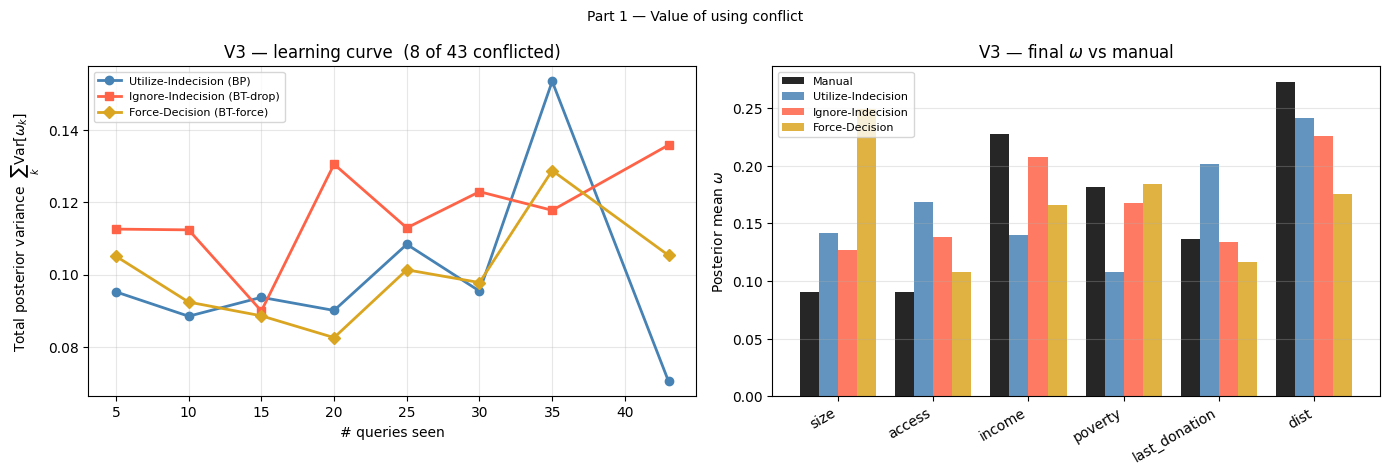

Saved v3_part1_value_of_conflict.png


In [10]:
# ─── Part 1 plot: Utilize-Indecision vs Ignore-Indecision vs Force-Decision ──
# Same data, three ways of using V3's 8 conflicted responses.

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Left: learning curve
ax = axes[0]
ax.plot(N_VALUES, lc['BP'], 'o-', color='steelblue', lw=2, label='Utilize-Indecision (BP)')
ax.plot(N_VALUES, lc['BT'], 's-', color='tomato',    lw=2, label='Ignore-Indecision (BT-drop)')
ax.plot(N_VALUES, lc['BF'], 'D-', color='goldenrod', lw=2, label='Force-Decision (BT-force)')
ax.set_xlabel('# queries seen')
ax.set_ylabel(r'Total posterior variance  $\sum_k \mathrm{Var}[\omega_k]$')
ax.set_title('V3 — learning curve  (8 of 43 conflicted)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Right: final ω comparison
ax = axes[1]
x = np.arange(_NDIM); width = 0.20
ax.bar(x - 1.5*width, om_manual,                 width, label='Manual',                color='black',     alpha=0.85)
ax.bar(x - 0.5*width, bp_samples.mean(axis=0),   width, label='Utilize-Indecision',    color='steelblue', alpha=0.85)
ax.bar(x + 0.5*width, bt_samples.mean(axis=0),   width, label='Ignore-Indecision',     color='tomato',    alpha=0.85)
ax.bar(x + 1.5*width, bf_samples.mean(axis=0),   width, label='Force-Decision',        color='goldenrod', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(FEATURES, rotation=30, ha='right')
ax.set_ylabel(r'Posterior mean $\omega$')
ax.set_title(r'V3 — final $\omega$ vs manual')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Part 1 — Value of using conflict', fontsize=10)
plt.tight_layout()
plt.savefig('v3_part1_value_of_conflict.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved v3_part1_value_of_conflict.png')


## Part 2 — Comparison against baselines that also model incomparability

This section asks: **how does Utilize-Indecision compare to other models that already allow ties / incomparability?**

We compare three baselines, all trained on the same full set of responses (conflicted → incomparable):

- **Utilize-Indecision** (Multi-Frame Polytope) — our method.
- **Rao-Kupper** ($\theta \geq 1$) — classic tie extension of Bradley-Terry. $P(\text{tie}) = (\theta^2-1) / [(1+\theta e^{-\Delta})(1+\theta e^{\Delta})]$. Reduces to BT at $\theta=1$.
- **Davidson** ($\nu \geq 0$) — alternative tie extension that preserves the Luce odds ratio $P(\text{left})/P(\text{right}) = e^\Delta$. $P(\text{tie}) = \nu / Z$. Reduces to BT at $\nu=0$.

All three share the same simplex prior, hit-and-run MCMC, and Block-Gibbs update for the tie parameter; posterior variance is reported on $\omega$ only.


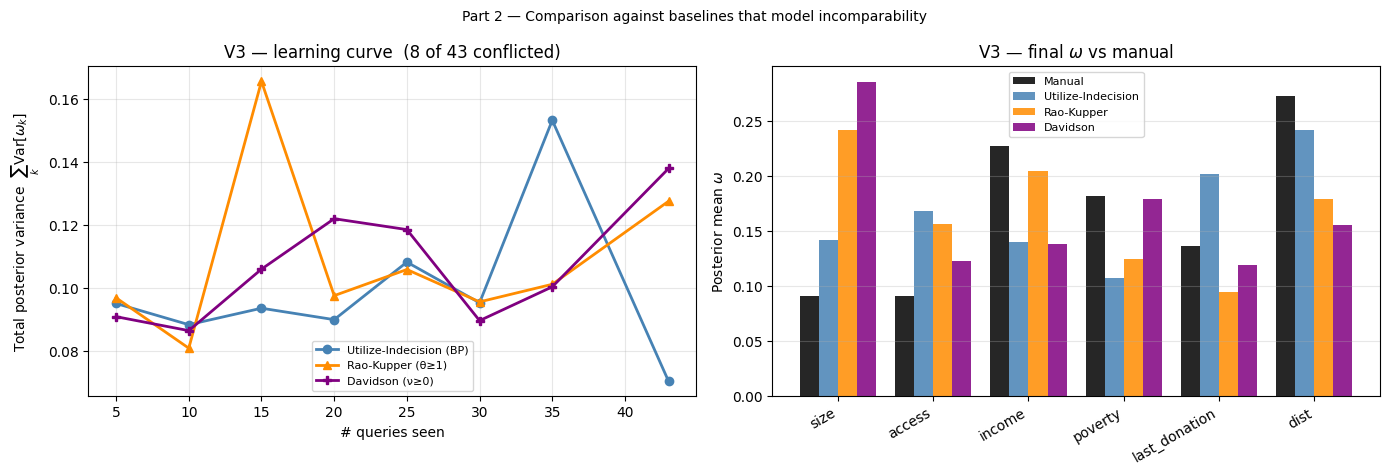

Saved v3_part2_incomparability_baselines.png


In [11]:
# ─── Part 2 plot: Utilize-Indecision vs Rao-Kupper vs Davidson ──────────────
# All three baselines model incomparability; same full transcript, uniform prior.

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Left: learning curve
ax = axes[0]
ax.plot(N_VALUES, lc['BP'], 'o-', color='steelblue',  lw=2, label='Utilize-Indecision (BP)')
ax.plot(N_VALUES, lc['RK'], '^-', color='darkorange', lw=2, label='Rao-Kupper (θ≥1)')
ax.plot(N_VALUES, lc['DV'], 'P-', color='purple',     lw=2, label='Davidson (ν≥0)')
ax.set_xlabel('# queries seen')
ax.set_ylabel(r'Total posterior variance  $\sum_k \mathrm{Var}[\omega_k]$')
ax.set_title('V3 — learning curve  (8 of 43 conflicted)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Right: final ω comparison
ax = axes[1]
x = np.arange(_NDIM); width = 0.20
ax.bar(x - 1.5*width, om_manual,                          width, label='Manual',             color='black',      alpha=0.85)
ax.bar(x - 0.5*width, bp_samples.mean(axis=0),            width, label='Utilize-Indecision', color='steelblue',  alpha=0.85)
ax.bar(x + 0.5*width, rk_samples[:, :_NDIM].mean(axis=0), width, label='Rao-Kupper',         color='darkorange', alpha=0.85)
ax.bar(x + 1.5*width, dv_samples[:, :_NDIM].mean(axis=0), width, label='Davidson',           color='purple',     alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(FEATURES, rotation=30, ha='right')
ax.set_ylabel(r'Posterior mean $\omega$')
ax.set_title(r'V3 — final $\omega$ vs manual')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Part 2 — Comparison against baselines that model incomparability', fontsize=10)
plt.tight_layout()
plt.savefig('v3_part2_incomparability_baselines.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved v3_part2_incomparability_baselines.png')


RK  θ (uniform prior on (1, 10]):
  mean   = 1.6663    median = 1.6428    std = 0.2633
  95% CI = [1.2211, 2.2287]
  samples within 1e-3 of lower bound (1.0): 0/500
  MCMC tie-param acceptance rate: 0.61

DV  ν (uniform prior on [0, 10]):
  mean   = 0.5585    median = 0.5259    std = 0.2013
  95% CI = [0.2391, 1.0865]
  samples within 1e-3 of lower bound (0.0): 0/500
  MCMC tie-param acceptance rate: 0.61



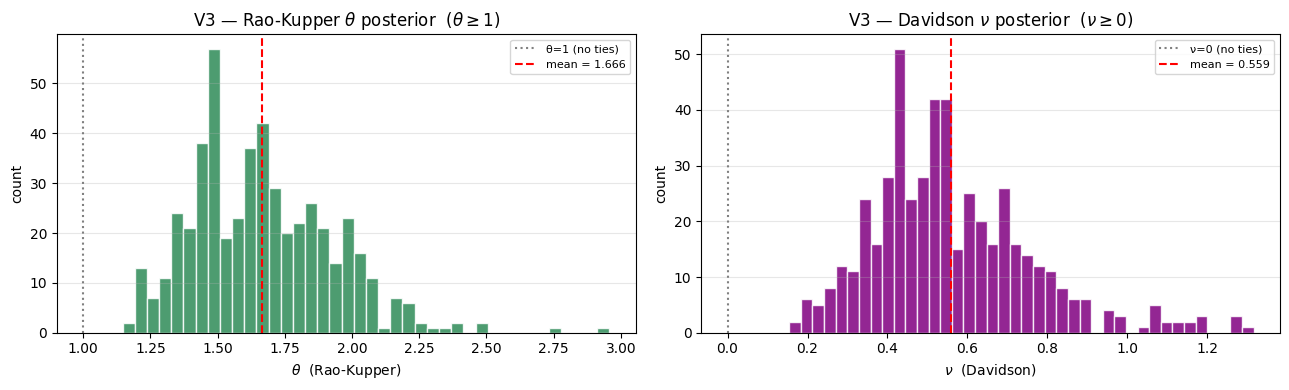

Saved v3_tie_param_posteriors.png


In [12]:
# ── Tie-parameter posteriors: RK θ (≥ 1) and Davidson ν (≥ 0) ─────────────
theta_samples = rk_samples[:, -1]
nu_samples    = dv_samples[:, -1]

def summarise(name, s, lower_bound, acc):
    print(f'{name}:')
    print(f'  mean   = {s.mean():.4f}    median = {np.median(s):.4f}    std = {s.std():.4f}')
    lo, hi = np.percentile(s, [2.5, 97.5])
    print(f'  95% CI = [{lo:.4f}, {hi:.4f}]')
    n_at_bound = int(np.sum(np.isclose(s, lower_bound, atol=1e-3)))
    print(f'  samples within 1e-3 of lower bound ({lower_bound}): {n_at_bound}/{len(s)}')
    print(f'  MCMC tie-param acceptance rate: {acc:.2f}\n')

summarise('RK  θ (uniform prior on (1, %g])' % _RK_THETA_MAX, theta_samples, 1.0, rk_acc_t)
summarise('DV  ν (uniform prior on [0, %g])' % _DV_NU_MAX,    nu_samples,    0.0, dv_acc_n)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(theta_samples, bins=40, color='seagreen', alpha=0.85, edgecolor='white')
ax.axvline(1.0, color='gray', ls=':', label='θ=1 (no ties)')
ax.axvline(theta_samples.mean(), color='red', ls='--', label=f'mean = {theta_samples.mean():.3f}')
ax.set_xlabel(r'$\theta$  (Rao-Kupper)'); ax.set_ylabel('count')
ax.set_title(r'V3 — Rao-Kupper $\theta$ posterior  ($\theta \geq 1$)')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.hist(nu_samples, bins=40, color='purple', alpha=0.85, edgecolor='white')
ax.axvline(0.0, color='gray', ls=':', label='ν=0 (no ties)')
ax.axvline(nu_samples.mean(), color='red', ls='--', label=f'mean = {nu_samples.mean():.3f}')
ax.set_xlabel(r'$\nu$  (Davidson)'); ax.set_ylabel('count')
ax.set_title(r'V3 — Davidson $\nu$ posterior  ($\nu \geq 0$)')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('v3_tie_param_posteriors.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved v3_tie_param_posteriors.png')

## Summary statistics — Utilize-Indecision vs all baselines

V3 has a single transcript (43 responses, 35 decisive, 8 conflicted), so each method produces one MCMC chain. We summarise:

- **Total posterior variance** $\sum_k \text{Var}[\omega_k]$ — lower is tighter.
- **Predictive accuracy** on V3's 35 decisive responses (in-sample, directional: does $\text{sign}(\phi^\top \bar{\omega})$ match A/B?).
- **L1 / L2 / cosine distance** between $\bar{\omega}$ and V3's manual ω.

The second table reports the difference relative to **Utilize-Indecision** (positive Δvar % means BP has lower variance; positive Δacc means BP is more accurate; positive ΔL1/ΔL2 means BP is closer to manual).


In [13]:
# ─── Summary stats: V3 across all 5 methods ─────────────────────────────────
import numpy as np

def _stats(omega_samples, label):
    om   = omega_samples.mean(axis=0)
    var  = float(omega_samples.var(axis=0).sum())
    pred = float((((phis_dec @ om) > 0) == ys_dec.astype(bool)).mean())
    l1   = float(np.abs(om - om_manual).sum())
    l2   = float(np.linalg.norm(om - om_manual))
    cos  = float(np.dot(om, om_manual) /
                 (np.linalg.norm(om) * np.linalg.norm(om_manual) + 1e-12))
    return {'label': label, 'omega': om, 'var': var, 'acc': pred,
            'l1': l1, 'l2': l2, 'cos': cos}

methods = [
    _stats(bp_samples,            'Utilize-Indecision (BP)'),
    _stats(bt_samples,            'Ignore-Indecision (BT-drop)'),
    _stats(bf_samples,            'Force-Decision (BT-force)'),
    _stats(rk_samples[:, :_NDIM], 'Rao-Kupper (θ≥1)'),
    _stats(dv_samples[:, :_NDIM], 'Davidson (ν≥0)'),
]

# ── Per-method absolute stats ───────────────────────────────────────────────
print(f'V3 — 43 responses (35 decisive, 8 conflicted)')
print('═' * 92)
print(f'{"Method":30s}  {"total var":>10s}  {"pred acc":>9s}  {"L1(ω-man)":>10s}  {"L2(ω-man)":>10s}  {"cos":>6s}')
print('─' * 92)
for m in methods:
    print(f'{m["label"]:30s}  {m["var"]:>10.5f}  {m["acc"]:>9.1%}  '
          f'{m["l1"]:>10.4f}  {m["l2"]:>10.4f}  {m["cos"]:>6.3f}')

# ── Utilize-Indecision (BP) vs each baseline ─────────────────────────────────
bp = methods[0]
print(f'\nUtilize-Indecision (BP) vs each baseline')
print('═' * 84)
print(f'{"Comparison":35s}  {"Δvar %":>9s}  {"Δacc":>7s}  {"ΔL1":>9s}  {"ΔL2":>9s}  {"Δcos":>7s}')
print('─' * 84)
for m in methods[1:]:
    dvar  = (m['var'] - bp['var']) / m['var']      # +ve = BP tighter
    dacc  =  bp['acc'] - m['acc']                   # +ve = BP more accurate
    dl1   =  m['l1']   - bp['l1']                   # +ve = BP closer to manual (lower L1)
    dl2   =  m['l2']   - bp['l2']                   # +ve = BP closer to manual (lower L2)
    dcos  =  bp['cos'] - m['cos']                   # +ve = BP higher cos similarity
    short = m['label'].replace('(BT-drop)','').replace('(BT-force)','').replace('(θ≥1)','').replace('(ν≥0)','').strip()
    tag = f'BP vs {m["label"]}'
    print(f'{tag:35s}  {dvar:>+8.1%}  {dacc:>+6.1%}  {dl1:>+8.4f}  {dl2:>+8.4f}  {dcos:>+6.3f}')

# ── Ranking summary ─────────────────────────────────────────────────────────
print(f'\nRankings (best → worst)')
print('─' * 50)
by_var  = sorted(methods, key=lambda m: m['var'])
by_acc  = sorted(methods, key=lambda m: -m['acc'])
by_l1   = sorted(methods, key=lambda m: m['l1'])
print('  by tightness (lowest var):       ' + '  >  '.join(m['label'].split(' (')[0] for m in by_var))
print('  by predictive accuracy:          ' + '  >  '.join(m['label'].split(' (')[0] for m in by_acc))
print('  by closeness to manual (L1):     ' + '  >  '.join(m['label'].split(' (')[0] for m in by_l1))

# ── Tie-parameter posterior summaries (for the two baselines that have them) ─
print(f'\nTie-parameter posteriors (Part 2 baselines)')
print('─' * 50)
theta_samples = rk_samples[:, -1]
nu_samples    = dv_samples[:, -1]
def _ci(s):
    lo, hi = np.percentile(s, [2.5, 97.5])
    return f'[{lo:.3f}, {hi:.3f}]'
print(f'  RK θ:        mean={theta_samples.mean():.3f}  median={np.median(theta_samples):.3f}  95% CI={_ci(theta_samples)}  (prior support [1, {_RK_THETA_MAX:g}])')
print(f'  Davidson ν:  mean={nu_samples.mean():.3f}  median={np.median(nu_samples):.3f}  95% CI={_ci(nu_samples)}  (prior support [0, {_DV_NU_MAX:g}])')


V3 — 43 responses (35 decisive, 8 conflicted)
════════════════════════════════════════════════════════════════════════════════════════════
Method                           total var   pred acc   L1(ω-man)   L2(ω-man)     cos
────────────────────────────────────────────────────────────────────────────────────────────
Utilize-Indecision (BP)            0.09808      91.4%      0.3866      0.1643   0.928
Ignore-Indecision (BT-drop)        0.10178      94.3%      0.1680      0.0801   0.984
Force-Decision (BT-force)          0.09718      94.3%      0.3560      0.1973   0.897
Rao-Kupper (θ≥1)                   0.10179      97.1%      0.4308      0.2028   0.891
Davidson (ν≥0)                     0.09752      94.3%      0.4531      0.2466   0.840

Utilize-Indecision (BP) vs each baseline
════════════════════════════════════════════════════════════════════════════════════
Comparison                              Δvar %     Δacc        ΔL1        ΔL2     Δcos
──────────────────────────────────────

## Tie-parameter identification confidence (V3)

How sure is each method about its tie parameter, given V3's 43 responses (8 conflicted)?

Three methods report uncertainty in different ways:

- **LP $\tau_\kappa$** — *strict feasibility interval* $[\tau_\text{lo}, \tau_\text{hi}]$. The LP makes no probabilistic statement; it reports the set of $\tau_\kappa$ for which the labels admit a consistent $\omega \in \Delta^6$. **For V3, no $\tau_\kappa$ admits the labels strictly** — V3's response set is mildly inconsistent with the BP decision rule for any single $\tau_\kappa$. We therefore fall back to:
  - **Soft-LP $\tau_\kappa$** — minimises the max constraint violation $s^*$. The "soft-feasibility band" $\{\tau_\kappa : s^*(\tau_\kappa) \le 1.05 \cdot s^*_\min\}$ acts as the LP-side uncertainty proxy.
- **Rao-Kupper $\theta$** — *posterior 95% CI* under uniform prior $[1, \Theta_\max]$.
- **Davidson $\nu$** — *posterior 95% CI* under uniform prior $[0, \nu_\max]$.

We also compare three *point estimates* on the LP side: the soft-feasibility band midpoint, the soft-LP $\tau_\kappa$ (min max violation), and the Chebyshev $\tau_\kappa$ (max constraint margin) — for V3 the latter only exists as a soft notion because the strict polytope is empty.


LP τ_κ inference: Chebyshev vs feasibility-only
──────────────────────────────────────────────────────────────────────
  ⚠  No τ_κ admits V3's labels strictly — strict feasibility is EMPTY.
  Min max-violation s*_min:              0.1047  (at τ_κ = 0.180)
  Soft-feasibility band (soft band (s* ≤ 1.05·s*_min)):
    [τ_lo, τ_hi]:                        [0.150, 0.200]
    Width:                                0.050
    Midpoint:                             0.175
  Soft-LP τ_κ (the paper's fallback):    0.180    ← used as τ_κ

Interpretation:
  - V3's labels are mildly inconsistent: there is no τ_κ for which the
    BP decision rule + V3's 43 labels admit a consistent ω. So the
    *strict* Chebyshev LP has no valid feasible polytope to centre.
  - We fall back to the soft-LP minimum-violation τ_κ, exactly as the
    τ_κ-inference cell does. The "soft band" reports the τ_κ values
    within 5% of the optimum violation — our LP-side uncertainty proxy.

Identification confidence — all three 

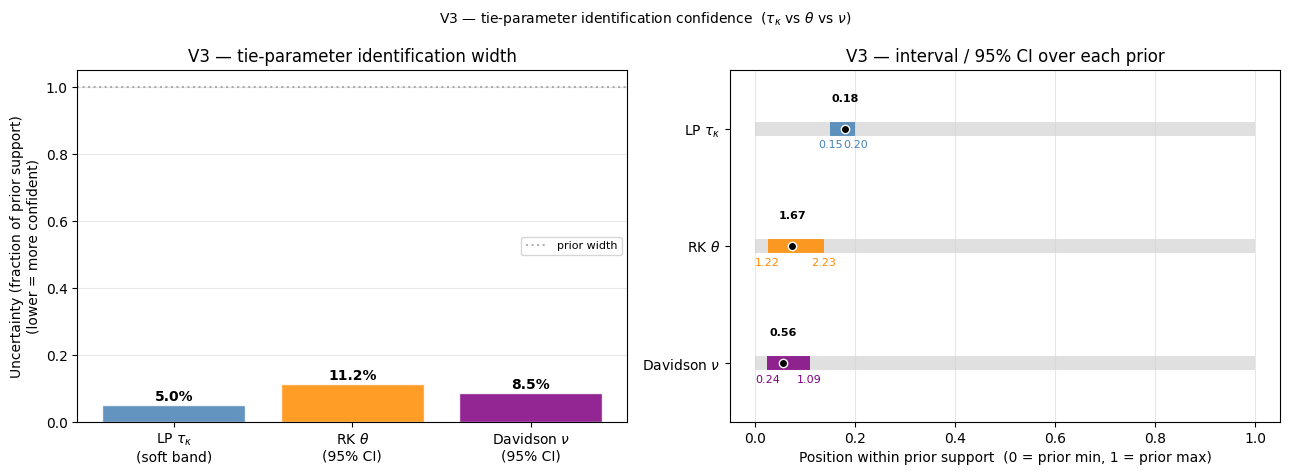

Saved v3_tie_param_confidence.png

Chebyshev vs feasibility-only point estimates
─────────────────────────────────────────────────────────────────
  Soft-band midpoint:               τ_κ = 0.175
  Soft-LP (min max violation):      τ_κ = 0.180    ← used in paper (V3 has no strict feas)
  Chebyshev (strict):                empty — no feasible polytope to centre

Posterior variance under each τ_κ choice (BP MCMC, V3 full transcript):
─────────────────────────────────────────────────────────────────
  τ_κ = 0.25 (default):     total var = 0.09808
  τ_κ = 0.18 (soft-LP):    total var = 0.12360


In [14]:
# ─── Tie-parameter identification confidence (V3) ───────────────────────────
# Reuses LP outputs from the τ_κ inference cell:
#   tau_grid, feasible_flags, max_viol, margin_t, tau_kappa_polytope, omega_polytope
# Reuses MCMC outputs:
#   rk_samples (last col = θ), dv_samples (last col = ν), bp_samples, bpi_var

import numpy as np

feas_idx = np.where(feasible_flags)[0]
strict_feasible = len(feas_idx) > 0

# ── LP point estimates (always defined) ─────────────────────────────────────
soft_idx  = int(np.argmin(max_viol))
tau_soft  = float(tau_grid[soft_idx])
min_viol  = float(max_viol[soft_idx])

# ── Branch on whether strict feasibility holds ──────────────────────────────
if strict_feasible:
    tau_lo  = float(tau_grid[feas_idx[0]])
    tau_hi  = float(tau_grid[feas_idx[-1]])
    feas_w  = tau_hi - tau_lo
    cheb_idx    = feas_idx[int(np.argmax(margin_t[feas_idx]))]
    tau_cheb    = float(tau_grid[cheb_idx])
    cheb_margin = float(margin_t[cheb_idx])
    band_label  = 'strict feas'
else:
    # Soft fallback: τ_κ where max-violation is within 5% of the minimum
    tol           = min_viol * 1.05
    soft_band_idx = np.where(max_viol <= tol)[0]
    if len(soft_band_idx) > 0:
        tau_lo = float(tau_grid[soft_band_idx[0]])
        tau_hi = float(tau_grid[soft_band_idx[-1]])
    else:
        tau_lo = tau_hi = tau_soft
    feas_w      = tau_hi - tau_lo
    tau_cheb    = tau_soft         # in soft mode, "Chebyshev" = soft-LP minimiser
    cheb_margin = float('nan')
    band_label  = 'soft band (s* ≤ 1.05·s*_min)'

tau_mid = (tau_lo + tau_hi) / 2.0

# ── Print Chebyshev-vs-feasibility comparison ───────────────────────────────
print('LP τ_κ inference: Chebyshev vs feasibility-only')
print('─' * 70)
if strict_feasible:
    print(f'  Strict feasibility holds.')
    print(f'  Feasibility interval [τ_lo, τ_hi]:    [{tau_lo:.3f}, {tau_hi:.3f}]')
    print(f'  Width:                                 {feas_w:.3f}')
    print(f'  Midpoint:                              {tau_mid:.3f}')
    print(f'  Soft-LP τ_κ (min max-violation):       {tau_soft:.3f}')
    print(f'  Chebyshev τ_κ (max margin t*):         {tau_cheb:.3f}    (t* = {cheb_margin:+.4f})')
    print()
    print('Interpretation:')
    print('  - Feasibility-only reports a SET of admissible τ_κ; every interior')
    print('    point gives some ω consistent with the labels.')
    print('  - Chebyshev picks the SINGLE τ_κ maximising slack to all constraints,')
    print('    biasing the choice toward the "fattest" part of the polytope.')
    print(f'  - Δ(Chebyshev − midpoint) = {tau_cheb - tau_mid:+.3f}')
else:
    print(f'  ⚠  No τ_κ admits V3\'s labels strictly — strict feasibility is EMPTY.')
    print(f'  Min max-violation s*_min:              {min_viol:.4f}  (at τ_κ = {tau_soft:.3f})')
    print(f'  Soft-feasibility band ({band_label}):')
    print(f'    [τ_lo, τ_hi]:                        [{tau_lo:.3f}, {tau_hi:.3f}]')
    print(f'    Width:                                {feas_w:.3f}')
    print(f'    Midpoint:                             {tau_mid:.3f}')
    print(f'  Soft-LP τ_κ (the paper\'s fallback):    {tau_soft:.3f}    ← used as τ_κ')
    print()
    print('Interpretation:')
    print('  - V3\'s labels are mildly inconsistent: there is no τ_κ for which the')
    print('    BP decision rule + V3\'s 43 labels admit a consistent ω. So the')
    print('    *strict* Chebyshev LP has no valid feasible polytope to centre.')
    print('  - We fall back to the soft-LP minimum-violation τ_κ, exactly as the')
    print('    τ_κ-inference cell does. The "soft band" reports the τ_κ values')
    print('    within 5% of the optimum violation — our LP-side uncertainty proxy.')

# ── RK θ and Davidson ν 95% CIs ──────────────────────────────────────────────
theta_samps = rk_samples[:, -1]
nu_samps    = dv_samples[:, -1]
theta_lo, theta_hi = np.percentile(theta_samps, [2.5, 97.5])
nu_lo,    nu_hi    = np.percentile(nu_samps,    [2.5, 97.5])
theta_w = float(theta_hi - theta_lo)
nu_w    = float(nu_hi    - nu_lo)

# ── Aggregate identification-confidence table ───────────────────────────────
print('\nIdentification confidence — all three tie parameters')
print('═' * 92)
band_str = 'strict feas' if strict_feasible else 'soft band'
print(f'{"method":18s}  {"point est.":>11s}  {"interval":>22s}  {"width":>7s}  {"prior":>7s}  {"frac %":>8s}')
print('─' * 92)
print(f'{f"LP τ_κ ({band_str})":18s}  {tau_cheb:>11.3f}  {f"[{tau_lo:.3f}, {tau_hi:.3f}]":>22s}  {feas_w:>7.3f}  {1.0:>7.1f}  {feas_w*100:>7.1f}%')
print(f'{"RK θ (≥1)":18s}  {theta_samps.mean():>11.3f}  {f"[{theta_lo:.3f}, {theta_hi:.3f}]":>22s}  {theta_w:>7.3f}  {_RK_THETA_MAX-1:>7.1f}  {theta_w/(_RK_THETA_MAX-1)*100:>7.1f}%')
print(f'{"Davidson ν":18s}  {nu_samps.mean():>11.3f}  {f"[{nu_lo:.3f}, {nu_hi:.3f}]":>22s}  {nu_w:>7.3f}  {_DV_NU_MAX:>7.1f}  {nu_w/_DV_NU_MAX*100:>7.1f}%')

# ── Plot: 2 panels ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Panel 1: width as fraction of prior support
ax = axes[0]
band_label_short = 'feas width' if strict_feasible else 'soft band'
labels = [r'LP $\tau_\kappa$' + f'\n({band_label_short})',
          r'RK $\theta$'      + '\n(95% CI)',
          r'Davidson $\nu$'   + '\n(95% CI)']
fracs  = [feas_w / 1.0,
          theta_w / (_RK_THETA_MAX - 1.0),
          nu_w    / _DV_NU_MAX]
colors = ['steelblue', 'darkorange', 'purple']
bars = ax.bar(labels, fracs, color=colors, alpha=0.85, edgecolor='white')
for bar, frac in zip(bars, fracs):
    ax.text(bar.get_x() + bar.get_width() / 2, frac + 0.005,
            f'{frac*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(1.0, color='gray', ls=':', alpha=0.6, label='prior width')
ax.set_ylim(0, max(1.05, max(fracs) * 1.25))
ax.set_ylabel('Uncertainty (fraction of prior support)\n(lower = more confident)')
ax.set_title('V3 — tie-parameter identification width')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# Panel 2: forest-style plot showing actual interval over prior support
ax = axes[1]
methods = [
    (r'LP $\tau_\kappa$',   [0.0, 1.0],            [tau_lo, tau_hi],     tau_cheb,           'steelblue'),
    (r'RK $\theta$',         [1.0, _RK_THETA_MAX],  [theta_lo, theta_hi], theta_samps.mean(), 'darkorange'),
    (r'Davidson $\nu$',      [0.0, _DV_NU_MAX],     [nu_lo, nu_hi],       nu_samps.mean(),    'purple'),
]
y_pos = np.arange(len(methods))
for y, (label, prior, ci, point, c) in zip(y_pos, methods):
    p_lo, p_hi = prior
    p_w = p_hi - p_lo
    ci_lo_n   = (ci[0] - p_lo) / p_w
    ci_hi_n   = (ci[1] - p_lo) / p_w
    point_n   = (point - p_lo) / p_w
    # Prior bar
    ax.plot([0, 1], [y, y], '-', color='lightgray', lw=10, alpha=0.7, solid_capstyle='butt')
    # Inferred interval
    ax.plot([ci_lo_n, ci_hi_n], [y, y], '-', color=c, lw=10, alpha=0.85, solid_capstyle='butt')
    # Point estimate
    ax.plot([point_n], [y], 'o', color='black', markersize=6, markeredgecolor='white', zorder=5)
    ax.text(ci_lo_n, y + 0.18, f'{ci[0]:.2f}',  ha='center', va='bottom', fontsize=8, color=c)
    ax.text(ci_hi_n, y + 0.18, f'{ci[1]:.2f}',  ha='center', va='bottom', fontsize=8, color=c)
    ax.text(point_n, y - 0.30, f'{point:.2f}',  ha='center', va='top',    fontsize=8, color='black', fontweight='bold')
ax.set_yticks(y_pos)
ax.set_yticklabels([m[0] for m in methods], fontsize=10)
ax.set_xlabel('Position within prior support  (0 = prior min, 1 = prior max)')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.5, len(methods) - 0.5)
ax.set_title('V3 — interval / 95% CI over each prior')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.suptitle('V3 — tie-parameter identification confidence  '
             r'($\tau_\kappa$ vs $\theta$ vs $\nu$)', fontsize=10)
plt.tight_layout()
plt.savefig('v3_tie_param_confidence.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved v3_tie_param_confidence.png')

# ── Numerical Chebyshev-vs-feasibility-only side-by-side ─────────────────────
print('\nChebyshev vs feasibility-only point estimates')
print('─' * 65)
if strict_feasible:
    print(f'  Feasibility midpoint:             τ_κ = {tau_mid:.3f}')
    print(f'  Soft-LP (min max violation):      τ_κ = {tau_soft:.3f}')
    print(f'  Chebyshev (max constraint slack): τ_κ = {tau_cheb:.3f}    ← used in paper')
else:
    print(f'  Soft-band midpoint:               τ_κ = {tau_mid:.3f}')
    print(f'  Soft-LP (min max violation):      τ_κ = {tau_soft:.3f}    ← used in paper (V3 has no strict feas)')
    print(f'  Chebyshev (strict):                empty — no feasible polytope to centre')
print()
print('Posterior variance under each τ_κ choice (BP MCMC, V3 full transcript):')
print('─' * 65)
print(f'  τ_κ = 0.25 (default):     total var = {bp_samples.var(axis=0).sum():.5f}')
print(f'  τ_κ = {tau_soft:.2f} (soft-LP):    total var = {bpi_var:.5f}')
